In [1]:
!rocm-smi


/bin/bash: line 1: rocm-smi: command not found


In [1]:
!nvidia-smi


Wed Mar  4 15:08:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.144.03             Driver Version: 550.144.03     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3080 Ti     Off |   00000000:2B:00.0 Off |                  N/A |
| 93%   73C    P2            343W /  350W |    6902MiB /  12288MiB |     96%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
!python -c "import torch; print('CUDA/ROCm Available:', torch.cuda.is_available()); print('Current Device:', torch.cuda.current_device()); x = torch.randn(1).to('cuda'); print('Success: Tensor moved to GPU')"

CUDA/ROCm Available: True
Current Device: 0
Success: Tensor moved to GPU


In [3]:

import json
import cv2
import numpy as np
import os
import zipfile
import torch
from torch.utils.data import Dataset
from PIL import Image
from transformers import Sam3Processor, Sam3Model
from torch.utils.data import DataLoader
from torch.optim import AdamW
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt
import random
import matplotlib.patches as patches
# from google.colab import files
from torch.cuda.amp import autocast, GradScaler  # <--- Needed for ROCm/W7900 Mixed Precision
import shutil                                     # <--- Needed for dataset file operations
from huggingface_hub import login



In [11]:
#Unzip your dataset

if os.path.exists("sam_finetuning_dataset.zip"):
    with zipfile.ZipFile("sam_finetuning_dataset.zip", 'r') as zip_ref:
        zip_ref.extractall(".")
    print("✅ Dataset unzipped successfully!")
else:
    print("⚠️ Error: Please upload 'sam_finetuning_dataset.zip' to the Files tab first.")

⚠️ Error: Please upload 'sam_finetuning_dataset.zip' to the Files tab first.


In [6]:
class CustomSAMDataset(Dataset):
    def __init__(self, json_file, root_dir, processor):
        self.root_dir = root_dir
        self.processor = processor
        
        with open(json_file, "r") as f:
            self.data = json.load(f)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # --- FIX: Use the keys that actually exist in your JSON ---
        # "image" instead of "image_path"
        # "annotation" instead of "mask_path"
        image_path = os.path.join(self.root_dir, item["image"]) 
        mask_path = os.path.join(self.root_dir, item["annotation"])
        
        # Load files
        image = Image.open(image_path).convert("RGB")
        ground_truth_mask = np.array(Image.open(mask_path).convert("L"))

        # "prompt_box" instead of "bbox"
        prompt_box = item["prompt_box"] 
        prompt_text = item["prompt_text"]  

        # Process inputs
        inputs = self.processor(
            image,
            input_boxes=[[prompt_box]],
            text=prompt_text,
            return_tensors="pt"
        )

        # Remove batch dimension
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}

        # Resize Ground Truth to 1024x1024 to match SAM's input size
        # This prevents the resolution mismatch error
        resized_mask = cv2.resize(ground_truth_mask, (1024, 1024), interpolation=cv2.INTER_NEAREST)
        inputs["ground_truth_mask"] = torch.tensor(resized_mask > 0).float()

        return inputs

In [7]:
# # --- CONFIGURATION ---
# BATCH_SIZE = 4            # Your W7900 has 48GB VRAM, so batch 4 is very safe and stable
# NUM_EPOCHS = 10          
# LEARNING_RATE = 1e-5
# WEIGHT_DECAY = 1e-4
# NUM_WORKERS = 4           # Fixes the speed bottleneck
# PIN_MEMORY = True         # Faster CPU -> GPU transfer
# # ---------------------

In [10]:
# --- CONFIGURATION (Adjusted for RTX 3080 Ti 12GB) ---
BATCH_SIZE = 1            # Reduced from 4 to 1 to fit in 12GB VRAM
NUM_EPOCHS = 5          
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2           # Adjusted for stability
PIN_MEMORY = True         # Keep True for faster data transfer
# ---------------------

In [ ]:
import os
import torch
from transformers import Sam3Processor, Sam3Model
from huggingface_hub import login

# 1. Secure Login
# Best practice: Set HF_TOKEN in your terminal export HF_TOKEN="hf_..."
# Or paste it here TEMPORARILY, but do not commit this file.

# 2. Load SAM 3
# Check the exact string on the Hugging Face model card.
model_id = "facebook/sam3" 
#KEY
print(f"Loading {model_id}...")
try:
    processor = Sam3Processor.from_pretrained(model_id)
    model = Sam3Model.from_pretrained(model_id)
except OSError:
    print("❌ Error: You might not have access. Go to the Hugging Face model page and accept the license terms first.")
    raise

# 3. Freeze Components
# 
# We freeze the 'Perception Encoder' (Vision) to keep the pre-trained knowledge.
# We only train the 'Mask Decoder' to learn your specific defects.
for name, param in model.named_parameters():
    if "mask_decoder" not in name:
        param.requires_grad = False
    else:
        param.requires_grad = True # Ensure decoder IS trainable
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"   Device: {torch.cuda.get_device_name(0)}")

model.to(device)
print("✅ Model loaded and vision encoder frozen.")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loading facebook/sam3...


Loading weights: 100%|██████████| 1468/1468 [00:01<00:00, 1027.97it/s, Materializing param=vision_encoder.neck.fpn_layers.3.proj2.weight]                       


   Device: NVIDIA GeForce RTX 3080 Ti
✅ Model loaded and vision encoder frozen.


In [11]:
# --- HELPER: Collate Function for SAM Batches ---
def sam_collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    input_boxes = torch.stack([item["input_boxes"] for item in batch])
    ground_truth_masks = torch.stack([item["ground_truth_mask"] for item in batch])
    input_ids = torch.stack([item["input_ids"] for item in batch])  # <--- ADD THIS
    
    return {
        "pixel_values": pixel_values,
        "input_boxes": input_boxes,
        "input_ids": input_ids,  # <--- ADD THIS
        "ground_truth_mask": ground_truth_masks
    }

# 2. Dataset Loading (Requires train.json / val.json)
if not os.path.exists("sam_finetuning_dataset/train.json"):
    raise FileNotFoundError("❌ 'train.json' not found. Please run the split_dataset script first.")

print("📂 Loading datasets...")
# Ensure your CustomSAMDataset class is defined before this!
train_dataset = CustomSAMDataset(
    json_file="sam_finetuning_dataset/train.json",
    root_dir="sam_finetuning_dataset",
    processor=processor
)
val_dataset = CustomSAMDataset(
    json_file="sam_finetuning_dataset/val.json",
    root_dir="sam_finetuning_dataset",
    processor=processor
)

# 3. Optimized DataLoaders with Collate Function
print(f"⚡ Creating High-Performance DataLoaders (Workers: {NUM_WORKERS})...")

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=NUM_WORKERS, 
    pin_memory=PIN_MEMORY,
    persistent_workers=True,
    collate_fn=sam_collate_fn # <--- ADDED THIS to prevent batching errors
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=NUM_WORKERS, 
    pin_memory=PIN_MEMORY,
    persistent_workers=True,
    collate_fn=sam_collate_fn # <--- ADDED THIS
)

print(f"✅ Training on {len(train_dataset)} examples, Validating on {len(val_dataset)} examples.")

📂 Loading datasets...
⚡ Creating High-Performance DataLoaders (Workers: 2)...
✅ Training on 1568 examples, Validating on 196 examples.


In [12]:
def dice_loss(inputs, targets, smooth=1.0):
    # Apply sigmoid to convert logits to probabilities
    inputs = torch.sigmoid(inputs)       
    
    # Flatten label and prediction tensors
    inputs = inputs.view(-1)
    targets = targets.view(-1)
    
    intersection = (inputs * targets).sum()                            
    dice = (2.*intersection + smooth) / (inputs.sum() + targets.sum() + smooth)  
    
    return 1 - dice

🔥 Starting Training for 5 Epochs on RTX 3080 Ti...


Epoch 1: Train=0.2916 | Val=0.2811 | LR=9.05e-06
   💾 Saved New Best Model! (Val Loss: 0.2811)


Epoch 2: Train=0.2702 | Val=0.2799 | LR=6.55e-06
   💾 Saved New Best Model! (Val Loss: 0.2799)


Epoch 3: Train=0.2544 | Val=0.2785 | LR=3.45e-06
   💾 Saved New Best Model! (Val Loss: 0.2785)


Epoch 4: Train=0.2490 | Val=0.2564 | LR=9.55e-07
   💾 Saved New Best Model! (Val Loss: 0.2564)


Epoch 5: Train=0.2423 | Val=0.2636 | LR=0.00e+00
📊 Saving Loss Curve to 'loss_curve.png'...
🎉 Done! Final Best Val Loss: 0.2564


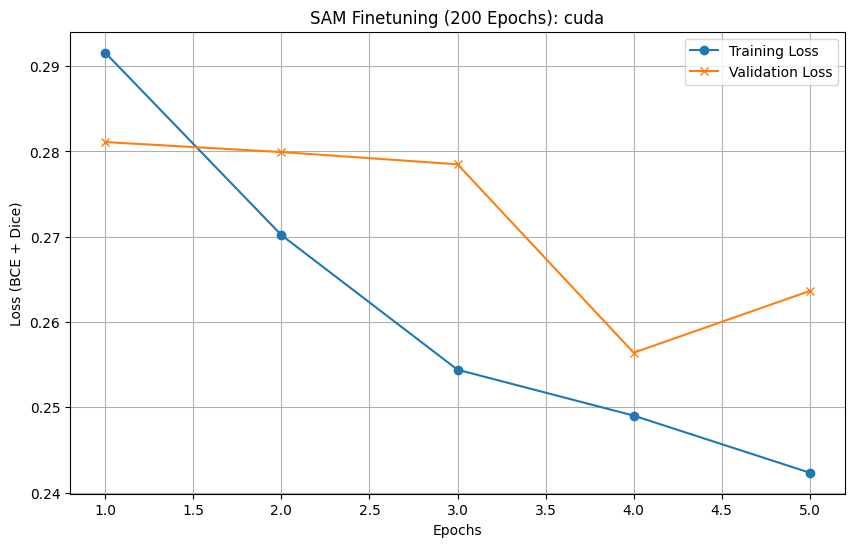

In [14]:
from torch.optim.lr_scheduler import CosineAnnealingLR

# 4. Training Setup
optimizer = AdamW(model.mask_decoder.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler('cuda')

# Scheduler: Smoothly decays learning rate over 200 epochs
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

best_val_loss = float('inf')
train_losses = []
val_losses = []

print(f"🔥 Starting Training for {NUM_EPOCHS} Epochs on RTX 3080 Ti...")

for epoch in range(NUM_EPOCHS):
    # --- TRAIN LOOP ---
    model.train()
    epoch_train_losses = []
    
    pbar = tqdm(train_loader, desc=f"Ep {epoch+1}/{NUM_EPOCHS}", leave=False)
    
    for batch in pbar:
        pixel_values = batch["pixel_values"].to(device, non_blocking=True)
        input_boxes = batch["input_boxes"].to(device, non_blocking=True)
        ground_truth_masks = batch["ground_truth_mask"].to(device, non_blocking=True)
        
        # Safety check for text prompt input_ids
        input_ids = batch.get("input_ids", None)
        if input_ids is not None:
            input_ids = input_ids.to(device, non_blocking=True)
            
        with torch.amp.autocast('cuda'):
            outputs = model(
                pixel_values=pixel_values, 
                input_boxes=input_boxes, 
                input_ids=input_ids,
                multimask_output=False
            )
            
            # Extract and upscale masks
            low_res_masks = outputs.pred_masks[:, 0, :, :]
            upscaled_masks = F.interpolate(
                low_res_masks.unsqueeze(1),
                size=(ground_truth_masks.shape[1], ground_truth_masks.shape[2]),
                mode="bilinear", 
                align_corners=False
            ).squeeze(1)
            
            # --- COMBINED LOSS (BCE + DICE) ---
            bce_loss = F.binary_cross_entropy_with_logits(upscaled_masks, ground_truth_masks.float())
            d_loss = dice_loss(upscaled_masks, ground_truth_masks.float())
            loss = (0.5 * bce_loss) + (0.5 * d_loss)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        epoch_train_losses.append(loss.item())
        pbar.set_postfix(train_loss=f"{loss.item():.4f}")

    # Step the scheduler after each training epoch
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    avg_train = np.mean(epoch_train_losses)
    train_losses.append(avg_train)

    # --- VALIDATION LOOP ---
    model.eval()
    epoch_val_losses = []
    
    with torch.no_grad():
        for batch in val_loader:
            pixel_values = batch["pixel_values"].to(device, non_blocking=True)
            input_boxes = batch["input_boxes"].to(device, non_blocking=True)
            ground_truth_masks = batch["ground_truth_mask"].to(device, non_blocking=True)

            input_ids = batch.get("input_ids", None)
            if input_ids is not None:
                input_ids = input_ids.to(device, non_blocking=True)

            with torch.amp.autocast('cuda'):
                # outputs = model(pixel_values=pixel_values, input_boxes=input_boxes, multimask_output=False)
                outputs = model(
                pixel_values=pixel_values, 
                input_boxes=input_boxes, 
                input_ids=input_ids,  # Now passing the text prompts
                multimask_output=False
            )

                low_res_masks = outputs.pred_masks[:, 0, :, :]
                upscaled_masks = F.interpolate(
                    low_res_masks.unsqueeze(1),
                    size=(ground_truth_masks.shape[1], ground_truth_masks.shape[2]),
                    mode="bilinear",
                    align_corners=False
                ).squeeze(1)
                
                v_bce = F.binary_cross_entropy_with_logits(upscaled_masks, ground_truth_masks.float())
                v_dice = dice_loss(upscaled_masks, ground_truth_masks.float())
                v_loss = (0.5 * v_bce) + (0.5 * v_dice)
            
            epoch_val_losses.append(v_loss.item())
            
    avg_val = np.mean(epoch_val_losses)
    val_losses.append(avg_val)

    # --- LOGGING & SAVING ---
    print(f"Epoch {epoch+1}: Train={avg_train:.4f} | Val={avg_val:.4f} | LR={current_lr:.2e}")
    
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), "sam_best_val_model.pth")
        print(f"   💾 Saved New Best Model! (Val Loss: {best_val_loss:.4f})")

    # Periodic Checkpoint (every 50 epochs) for long runs
    if (epoch + 1) % 50 == 0:
        torch.save(model.state_dict(), f"sam_model_checkpoint_ep{epoch+1}.pth")

# 5. Save Plot
print("📊 Saving Loss Curve to 'loss_curve.png'...")
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', marker='x')
plt.xlabel('Epochs')
plt.ylabel('Loss (BCE + Dice)')
plt.title(f'SAM Finetuning (200 Epochs): {device}')
plt.legend()
plt.grid(True)
plt.savefig('loss_curve.png')
print(f"🎉 Done! Final Best Val Loss: {best_val_loss:.4f}")

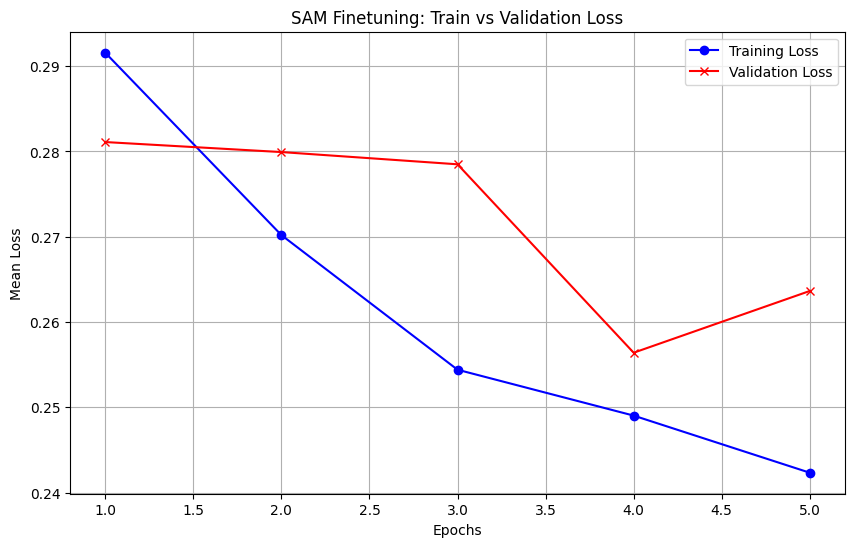

In [16]:
# Plotting Train vs Validation Loss
plt.figure(figsize=(10, 6))

# Plot Training Loss (Blue)
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, marker='o', color='b', label='Training Loss')

# Plot Validation Loss (Red)
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, marker='x', color='r', label='Validation Loss')

plt.title('SAM Finetuning: Train vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Loss')
plt.grid(True)
plt.legend()
plt.show()

In [17]:
# # 1. Load the Best Saved Model
# model.load_state_dict(torch.load("sam_best_val_model.pth"))
# model.to(device)
# model.eval()

# # 2. Setup Test Loader
# test_dataset = CustomSAMDataset(
#     json_file="sam_finetuning_dataset/test.json",
#     root_dir="sam_finetuning_dataset",
#     processor=processor
# )
# test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# print(f"🧪 Testing on {len(test_dataset)} unseen images...")

# test_losses = []

# with torch.no_grad():
#     for i, batch in enumerate(test_loader):
#         pixel_values = batch["pixel_values"].to(device)
#         input_boxes = batch["input_boxes"].to(device)
#         ground_truth_masks = batch["ground_truth_mask"].to(device)

#         outputs = model(pixel_values=pixel_values, input_boxes=input_boxes, multimask_output=False)

#         # Calculate Loss
#         predicted_masks = outputs.pred_masks.squeeze(1)
#         predicted_mask = predicted_masks[:, 0, :, :]
#         loss = F.binary_cross_entropy_with_logits(predicted_mask, ground_truth_masks)
#         test_losses.append(loss.item())

#         # Optional: Visualize every 5th test image
#         if i % 5 == 0:
#             pred_binary = (predicted_mask > 0).cpu().numpy()[0]
#             gt_binary = ground_truth_masks.cpu().numpy()[0]

#             fig, ax = plt.subplots(1, 2, figsize=(10, 5))
#             ax[0].imshow(gt_binary, cmap='gray')
#             ax[0].set_title("Ground Truth")
#             ax[1].imshow(pred_binary, cmap='gray')
#             ax[1].set_title(f"Prediction (Loss: {loss.item():.4f})")
#             plt.show()

# print(f"📊 Final Test Set Average Loss: {np.mean(test_losses):.4f}")

🧪 Testing on 196 unseen images...


ValueError: You must specify exactly one of input_ids or text_embeds

In [18]:
# 1. Load the Best Saved Model
model.load_state_dict(torch.load("sam_best_val_model.pth"))
model.to(device)
model.eval()

# 2. Setup Test Loader
test_dataset = CustomSAMDataset(
    json_file="sam_finetuning_dataset/test.json",
    root_dir="sam_finetuning_dataset",
    processor=processor
)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"🧪 Testing on {len(test_dataset)} unseen images...")

test_losses = []

with torch.no_grad():
    for i, batch in enumerate(test_loader):
        pixel_values = batch["pixel_values"].to(device, non_blocking=True)
        input_boxes = batch["input_boxes"].to(device, non_blocking=True)
        ground_truth_masks = batch["ground_truth_mask"].to(device, non_blocking=True)
        
        # --- FIX 1: Add input_ids to prevent the ValueError ---
        input_ids = batch.get("input_ids", None)
        if input_ids is not None:
            input_ids = input_ids.to(device, non_blocking=True)

        with torch.amp.autocast('cuda'):
            outputs = model(
                pixel_values=pixel_values, 
                input_boxes=input_boxes, 
                input_ids=input_ids,  # Added input_ids
                multimask_output=False
            )

            # --- FIX 2: Handle Resolution Mismatch (Upscale) ---
            low_res_masks = outputs.pred_masks[:, 0, :, :]
            upscaled_masks = F.interpolate(
                low_res_masks.unsqueeze(1),
                size=(ground_truth_masks.shape[1], ground_truth_masks.shape[2]),
                mode="bilinear",
                align_corners=False
            ).squeeze(1)

            # Calculate Loss (using same BCE + Dice logic as training)
            v_bce = F.binary_cross_entropy_with_logits(upscaled_masks, ground_truth_masks.float())
            v_dice = dice_loss(upscaled_masks, ground_truth_masks.float())
            loss = (0.5 * v_bce) + (0.5 * v_dice)
            
        test_losses.append(loss.item())

        # Optional: Visualize every 5th test image
        if i % 5 == 0:
            # Threshold the logits to get a binary mask (0.0 is the center for logits)
            pred_binary = (upscaled_masks > 0).cpu().numpy()[0]
            gt_binary = ground_truth_masks.cpu().numpy()[0]

            fig, ax = plt.subplots(1, 2, figsize=(10, 5))
            ax[0].imshow(gt_binary, cmap='gray')
            ax[0].set_title("Ground Truth")
            ax[1].imshow(pred_binary, cmap='gray')
            ax[1].set_title(f"Prediction (Loss: {loss.item():.4f})")
            
            # Save the figure instead of plt.show() so you can view it later
            plt.savefig(f'test_result_{i}.png')
            plt.close() # Close to save memory

print(f"📊 Final Test Set Average Loss: {np.mean(test_losses):.4f}")

🧪 Testing on 196 unseen images...
📊 Final Test Set Average Loss: 0.2599


In [3]:
import os
import torch
import random
import numpy as np
import cv2
import matplotlib
matplotlib.use('Agg') # Essential for Linux servers/tmux
import matplotlib.pyplot as plt
from PIL import Image
import torch
from transformers import Sam3Processor, Sam3Model
from huggingface_hub import login

# 1. SETUP PATHS
MODEL_CHECKPOINT = "sam_model_checkpoint_ep100.pth" # Ensure this matches your filename
DATASET_PATH = "sam_finetuning_dataset"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 2. LOAD MODEL AND PROCESSOR
print(f"Loading model from {MODEL_CHECKPOINT}...")
model_id = "facebook/sam3" 

#KEY
print(f"Loading {model_id}...")
try:
    processor = Sam3Processor.from_pretrained(model_id)
    model = Sam3Model.from_pretrained(model_id)
except OSError:
    print("❌ Error: You might not have access. Go to the Hugging Face model page and accept the license terms first.")
    raise


# Load your fine-tuned weights
model.load_state_dict(torch.load(MODEL_CHECKPOINT, map_location=DEVICE))
model.to(DEVICE)
model.eval()

# 3. SELECT IMAGE (Arrow Filter)
# Assuming 'dataset' is already initialized in your environment or re-loading metadata here
# If you don't have the 'dataset' object, we use the raw metadata
import json
with open(os.path.join(DATASET_PATH, "train.json"), "r") as f:
    metadata = json.load(f)

arrow_indices = [i for i, item in enumerate(metadata) if "arrow" in item.get("prompt_text", "").lower()]

if arrow_indices:
    idx = random.choice(arrow_indices)
    print(f"✅ Selected Arrow Index {idx}: '{metadata[idx]['prompt_text']}'")
else:
    idx = random.randint(0, len(metadata) - 1)
    print(f"⚠️ No arrow found. Selected Random Index {idx}")

# 4. PREPARE INPUTS
item = metadata[idx]

# 'image' is the medical scan (input)
image_path = os.path.join(DATASET_PATH, item["image"]) 
image = Image.open(image_path).convert("RGB")

# 'annotation' is the mask/label (ground truth)
gt_mask_path = os.path.join(DATASET_PATH, item["annotation"])
# Convert to "L" (8-bit pixels, black and white) to fix the Reshape error
ground_truth_mask = np.array(Image.open(gt_mask_path).convert("L")) 

# Extract the prompt box
prompt_box = item["prompt_box"]

# Process for SAM3
inputs = processor(image, input_boxes=[[prompt_box]], return_tensors="pt").to(DEVICE)
# 5. RUN INFERENCE
print("Running inference...")
with torch.no_grad():
    outputs = model(**inputs, multimask_output=False)

# Convert logits to binary mask
raw_mask = outputs.pred_masks.cpu().numpy()
prediction = np.squeeze(raw_mask)
if prediction.ndim == 3: prediction = prediction[0]
prediction = (prediction > 0.0).astype(np.uint8)

# # 6. VISUALIZATION FUNCTIONS
# def show_box(box, ax):
#     x0, y0 = box[0], box[1]
#     w, h = box[2] - box[0], box[3] - box[1]
#     ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='lime', facecolor=(0,0,0,0), lw=2))

# def show_mask(mask, ax, color):
#     mask_image = mask.reshape(mask.shape[0], mask.shape[1], 1) * color.reshape(1, 1, -1)
#     ax.imshow(mask_image)

# # 7. PLOTTING
# fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# # Plot A: Input + Box
# axes[0].imshow(image)
# show_box(prompt_box, axes[0])
# axes[0].set_title(f"Input: {item.get('prompt_text', 'Box')}")
# axes[0].axis('off')

# # Plot B: Ground Truth
# axes[1].imshow(image)
# gt_resized = cv2.resize(ground_truth_mask.astype(np.float32), (image.width, image.height))
# show_mask((gt_resized > 0), axes[1], np.array([1, 0, 0, 0.5])) # Red for GT
# axes[1].set_title("Ground Truth (Manual Label)")
# axes[1].axis('off')

# # Plot C: Prediction
# axes[2].imshow(image)
# pred_resized = cv2.resize(prediction.astype(np.float32), (image.width, image.height))
# show_mask((pred_resized > 0), axes[2], np.array([0, 1, 0, 0.5])) # Green for Pred
# axes[2].set_title("Fine-Tuned SAM Prediction")
# axes[2].axis('off')
# 6. UPDATED VISUALIZATION FUNCTIONS
def show_mask(mask, ax, color):
    # Ensure mask is a binary 0/1 array
    mask = (mask > 0).astype(np.uint8)
    
    # Check if mask is empty (debugging)
    if np.max(mask) == 0:
        print("⚠️ Warning: Mask appears to be empty (all zeros).")
        
    h, w = mask.shape[-2:]
    # Reshape and apply color
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

# 7. UPDATED PLOTTING
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot A: Raw Image + Box
axes[0].imshow(image)
show_box(prompt_box, axes[0])
axes[0].set_title("Input & Prompt Box")
axes[0].axis('off')

# Plot B: Ground Truth (RED)
axes[1].imshow(image)
gt_resized = cv2.resize(ground_truth_mask, (image.width, image.height), interpolation=cv2.INTER_NEAREST)
# Using a brighter red with 0.7 alpha for better visibility
show_mask(gt_resized, axes[1], np.array([1, 0, 0, 0.7])) 
axes[1].set_title(f"Label: {item['label']}")
axes[1].axis('off')

# Plot C: Prediction (GREEN)
axes[2].imshow(image)
pred_resized = cv2.resize(prediction, (image.width, image.height), interpolation=cv2.INTER_NEAREST)
# Using a bright green with 0.7 alpha
show_mask(pred_resized, axes[2], np.array([0, 1, 0, 0.7]))
axes[2].set_title("SAM3 Prediction")
axes[2].axis('off')
# 8. SAVE RESULT
output_filename = f"test_result_idx_{idx}.png"
plt.tight_layout()
plt.savefig(output_filename)
print(f"🚀 Success! Result saved as: {output_filename}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loading model from sam_model_checkpoint_ep100.pth...
Loading facebook/sam3...


Loading weights: 100%|██████████| 1468/1468 [00:01<00:00, 981.65it/s, Materializing param=vision_encoder.neck.fpn_layers.3.proj2.weight]                        


✅ Selected Arrow Index 811: 'green arrow'
Running inference...
⚠️ Warning: Mask appears to be empty (all zeros).
🚀 Success! Result saved as: test_result_idx_811.png


In [5]:
import os
import torch
import random
import numpy as np
import cv2
import matplotlib
matplotlib.use('Agg') 
import matplotlib.pyplot as plt
from PIL import Image
from transformers import Sam3Processor, Sam3Model

# 1. SETUP PATHS
MODEL_CHECKPOINT = "sam_model_checkpoint_ep100.pth" # Ensure this matches your filename
DATASET_PATH = "sam_finetuning_dataset"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 2. LOAD MODEL AND PROCESSOR
print(f"Loading model from {MODEL_CHECKPOINT}...")
model_id = "facebook/sam3" 

#KEY

print(f"Loading {model_id}...")
try:
    processor = Sam3Processor.from_pretrained(model_id)
    model = Sam3Model.from_pretrained(model_id)
except OSError:
    print("❌ Error: You might not have access. Go to the Hugging Face model page and accept the license terms first.")
    raise


# Load your fine-tuned weights
model.load_state_dict(torch.load(MODEL_CHECKPOINT, map_location=DEVICE))
model.to(DEVICE)
model.eval()
# 3. SELECT DATA
with open(os.path.join(DATASET_PATH, "train.json"), "r") as f:
    metadata = json.load(f)

arrow_indices = [i for i, item in enumerate(metadata) if "arrow" in item.get("prompt_text", "").lower()]
idx = random.choice(arrow_indices) if arrow_indices else random.randint(0, len(metadata)-1)
item = metadata[idx]

# 4. LOAD FILES (Corrected Mapping)
image = Image.open(os.path.join(DATASET_PATH, item["image"])).convert("RGB")
# Load mask as grayscale and force to binary 0/1
gt_mask = np.array(Image.open(os.path.join(DATASET_PATH, item["annotation"])).convert("L"))
gt_mask = (gt_mask > 0).astype(np.uint8) 

# 5. INFERENCE
prompt_box = item["prompt_box"]
inputs = processor(image, input_boxes=[[prompt_box]], return_tensors="pt").to(DEVICE)

with torch.no_grad():
    outputs = model(**inputs, multimask_output=False)
    
pred_mask = (torch.sigmoid(outputs.pred_masks) > 0.5).cpu().numpy().squeeze().astype(np.uint8)
# 6. IMPROVED VISUALIZATION (Contours with Case-Sensitive Fix)
def draw_result(ax, img, mask, color_rgb, title):
    ax.imshow(img)
    
    # Ensure mask is the right size and type
    mask_res = cv2.resize(mask.astype(np.uint8), (img.width, img.height), interpolation=cv2.INTER_NEAREST)
    
    if np.any(mask_res):
        # Find contours
        contours, _ = cv2.findContours(mask_res, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            if len(cnt) > 2: # Need at least 3 points for a polygon
                # FIX: Use lowercase 'edgecolor' and 'facecolor'
                poly = plt.Polygon(
                    cnt.reshape(-1, 2), 
                    edgecolor=color_rgb, 
                    facecolor=(*color_rgb[:3], 0.3), 
                    lw=2
                )
                ax.add_patch(poly)
    else:
        # If no pixels are found, display a warning on the plot
        ax.text(img.width//4, img.height//2, "EMPTY MASK", color='yellow', 
                fontsize=15, fontweight='bold', bbox={'facecolor': 'red', 'alpha': 0.7})
        
    ax.set_title(title)
    ax.axis('off')

# 7. PLOT EXECUTION
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Plot A: Input Image + Bounding Box
axes[0].imshow(image)
x0, y0, x1, y1 = prompt_box
rect = plt.Rectangle((x0, y0), x1-x0, y1-y0, edgecolor='lime', facecolor='none', lw=2)
axes[0].add_patch(rect)
axes[0].set_title(f"Input & Box (Idx: {idx})")
axes[0].axis('off')

# Plot B: Ground Truth (Red Outline)
# color_rgb is (1, 0, 0) for pure Red
draw_result(axes[1], image, gt_mask, (1, 0, 0), "Ground Truth (Label)")

# Plot C: Prediction (Cyan Outline)
# color_rgb is (0, 1, 1) for bright Cyan
draw_result(axes[2], image, pred_mask, (0, 1, 1), "SAM3 Fine-Tuned Prediction")

plt.tight_layout()
output_name = f"final_test_result_{idx}.png"
plt.savefig(output_name, dpi=150)
print(f"✅ Visualization saved to: {output_name}")
plt.close()

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loading model from sam_model_checkpoint_ep100.pth...
Loading facebook/sam3...


Loading weights: 100%|██████████| 1468/1468 [00:01<00:00, 1317.04it/s, Materializing param=vision_encoder.neck.fpn_layers.3.proj2.weight]                       


error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/contours_new.cpp:332: error: (-2:Unspecified error) in function 'static std::shared_ptr<ContourScanner_> ContourScanner_::create(cv::ContourDataStorage<cv::Point_<int>, 1024, 0>::storage_t&, cv::ContourDataStorage<signed char, 1024, 0>::storage_t&, cv::Mat, int, int, cv::Point)'
> Modes other than RETR_FLOODFILL and RETR_CCOMP support only CV_8UC1 images (expected: 'img.type() == CV_8UC1'), where
>     'img.type()' is 2296 (CV_8UC288)
> must be equal to
>     'CV_8UC1' is 0 (CV_8UC1)


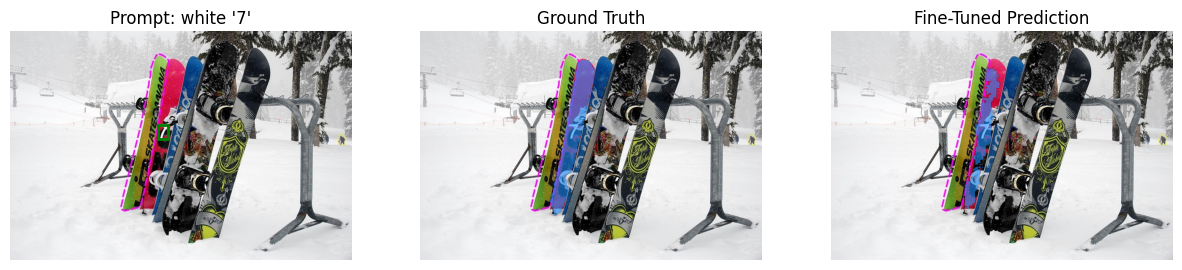

In [ ]:


# # # --- NEW: Filter for Arrows ---
# # # Find all indices where the prompt text contains "arrow"
# # arrow_indices = [i for i, item in enumerate(dataset.data) if "arrow" in item.get("prompt_text", "").lower()]

# # if not arrow_indices:
# #     print("⚠️ No arrow prompts found in dataset metadata.")
# #     print("Falling back to random selection (update prepare_dataset.py to fix this).")
# #     idx = random.randint(0, len(dataset) - 1)
# # else:
# #     idx = random.choice(arrow_indices)
# #     print(f"✅ Selected Index {idx} (Prompt: '{dataset.data[idx]['prompt_text']}')")
# # ------------------------------
# idx = random.randint(0, len(dataset) - 1)
# item = dataset[idx]

# # Prepare Inputs
# image_path = os.path.join("sam_finetuning_dataset", dataset.data[idx]["image"])
# image = Image.open(image_path).convert("RGB")
# prompt_box = dataset.data[idx]["prompt_box"]
# ground_truth_mask = item["ground_truth_mask"].numpy()

# # Run Inference
# device = "cuda" if torch.cuda.is_available() else "cpu"
# model.eval()
# inputs = processor(image, input_boxes=[[prompt_box]], return_tensors="pt").to(device)

# with torch.no_grad():
#     outputs = model(**inputs, multimask_output=False)

# # Process Result
# raw_mask = outputs.pred_masks.cpu().numpy()
# prediction = np.squeeze(raw_mask)
# if prediction.ndim == 3: prediction = prediction[0] # Safety check
# prediction = (prediction > 0.0).astype(np.uint8)

# # Visualization
# def show_box(box, ax):
#     x0, y0 = box[0], box[1]
#     w, h = box[2] - box[0], box[3] - box[1]
#     ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))

# def show_mask(mask, ax, color=None):
#     if color is None: color = np.array([30/255, 144/255, 255/255, 0.6])
#     if mask.ndim > 2: mask = mask.squeeze()
#     h, w = mask.shape[-2:]
#     mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
#     ax.imshow(mask_image)

# fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# # Plot A: Input
# axes[0].imshow(image)
# show_box(prompt_box, axes[0])
# axes[0].set_title(f"Prompt: {dataset.data[idx].get('prompt_text', 'Box')}")
# axes[0].axis('off')

# # Plot B: Ground Truth
# axes[1].imshow(image)
# gt_resized = cv2.resize(ground_truth_mask.astype(np.float32), (image.width, image.height))
# gt_resized = (gt_resized > 0.5).astype(np.float32)
# show_mask(gt_resized, axes[1])
# axes[1].set_title("Ground Truth")
# axes[1].axis('off')

# # Plot C: Prediction
# axes[2].imshow(image)
# prediction_resized = cv2.resize(prediction.astype(np.float32), (image.width, image.height))
# prediction_resized = (prediction_resized > 0.5).astype(np.float32)
# show_mask(prediction_resized, axes[2])
# axes[2].set_title("Fine-Tuned Prediction")
# axes[2].axis('off')

# plt.show()

In [ ]:
# # Save the current state
# torch.save(model.state_dict(), "sam_finetuned_epoch.pth")
# print("✅ Saved checkpoint for Epoch 10")

✅ Saved checkpoint for Epoch 10


In [ ]:


# # Check if the file exists before trying to download
# if os.path.exists("sam_best_model.pth"):
#     print("⬇️ Downloading best model...")
#     files.download("sam_best_model.pth")
# else:
#     print("⚠️ Model file not found. Make sure training finished and saved 'sam_best_model.pth'.")

In [ ]:
# model = SamModel.from_pretrained("facebook/sam-vit-base")
# # Load your custom weights
# model.load_state_dict(torch.load("sam_best_model.pth", map_location="cuda"))

In [ ]:


# # --- CONFIGURATION ---
# TEST_IMAGE_PATH = "my_new_test_image.jpg"  # Upload a NEW image to test!
# MODEL_PATH = "sam_best_model.pth"
# # ---------------------

# # 1. Load Model
# device = "cuda" if torch.cuda.is_available() else "cpu"
# model = SamModel.from_pretrained("facebook/sam-vit-base")
# processor = SamProcessor.from_pretrained("facebook/sam-vit-base")
# model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
# model.to(device)
# model.eval()

# # 2. Auto-Detect Prompt (Magic Inference)
# def magic_inference(image_path):
#     image_cv = cv2.imread(image_path)
#     if image_cv is None: return
#     image_rgb = cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)

#     # Detect colorful markings (red, green, blue, yellow, etc.)
#     # We combine masks for common annotation colors
#     hsv = cv2.cvtColor(image_cv, cv2.COLOR_BGR2HSV)

#     # Tuning for "Not Grayscale" (Saturation > 40)
#     # This ignores the photo and finds the colorful paint
#     mask_color = cv2.inRange(hsv, (0, 40, 40), (180, 255, 255))

#     contours, _ = cv2.findContours(mask_color, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#     if not contours:
#         print("⚠️ No annotation detected! Draw a colorful arrow/box first.")
#         return

#     # Assume largest color blob is the prompt
#     largest_contour = max(contours, key=cv2.contourArea)
#     x, y, w, h = cv2.boundingRect(largest_contour)
#     prompt_box = [x, y, x+w, y+h]

#     print(f"🎯 Detected Prompt Box: {prompt_box}")

#     # Run SAM
#     inputs = processor(Image.fromarray(image_rgb), input_boxes=[[prompt_box]], return_tensors="pt").to(device)
#     with torch.no_grad():
#         outputs = model(**inputs, multimask_output=False)

#     # Visualise
#     prediction = outputs.pred_masks[0, 0].cpu().numpy() > 0.5

#     plt.figure(figsize=(10, 10))
#     plt.imshow(image_rgb)
#     plt.imshow(prediction, alpha=0.5)
#     # Draw the box we found
#     plt.gca().add_patch(plt.Rectangle((x, y), w, h, edgecolor='yellow', facecolor='none', lw=2))
#     plt.title("Did it work on a new image?")
#     plt.axis('off')
#     plt.show()

# # Run it
# magic_inference(TEST_IMAGE_PATH)